# Scaling & Encoding — The Preprocessing Pipeline

**Goal:** Build a reusable, leak-free preprocessing pipeline using `Pipeline`, `ColumnTransformer`, and sklearn transformers.

**Why it matters:** Raw data can never go into a model as-is. Numbers must be scaled, categories must be encoded, and — crucially — all of this must happen *inside* cross-validation to avoid data leakage.

**Prerequisite:** [01-missing-outliers.ipynb](./01-missing-outliers.ipynb)

**Dataset:** Titanic .

---

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.preprocessing import StandardScaler , MinMaxScaler , RobustScaler
from sklearn.preprocessing import LabelEncoder , OneHotEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

sns.set_style('darkgrid')
plt.rcParams["figure.figsize"] = (10, 5)
np.random.seed(42)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)

Shape: (891, 12)


##  Quick Clean (recap)

Re-apply the cleaning decisions from previous notebooks. We keep only model-ready columns.

In [52]:
# Basic feature engineering
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Drop columns that won't reach the model
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Impute Age group-wise (as decided before)
df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(lambda x: x.fillna(x.median()))

# Fill Embarked mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

print("Shape:", df.shape)
print("Missing:", df.isnull().sum().sum())
df.head(3)

Shape: (891, 11)
Missing: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,0,2,0
1,1,1,female,38.0,1,0,71.2833,C,1,2,0
2,1,3,female,26.0,0,0,7.9250,S,0,1,1


##  Why Scale?

Many ML algorithms are **distance-based** or **gradient-based**. If one feature has range `[0, 500]` and another `[0, 1]`, the large-range feature dominates — not because it's more important, but because it's larger.

**Algorithms that NEED scaling:**
- KNN, SVM, K-Means
- PCA, Neural Networks
- Logistic Regression with regularization

**Algorithms that DON'T need scaling:**
- Decision Trees, Random Forest, XGBoost, LightGBM
(Trees split on thresholds, so monotonic transforms don't change them.)

---

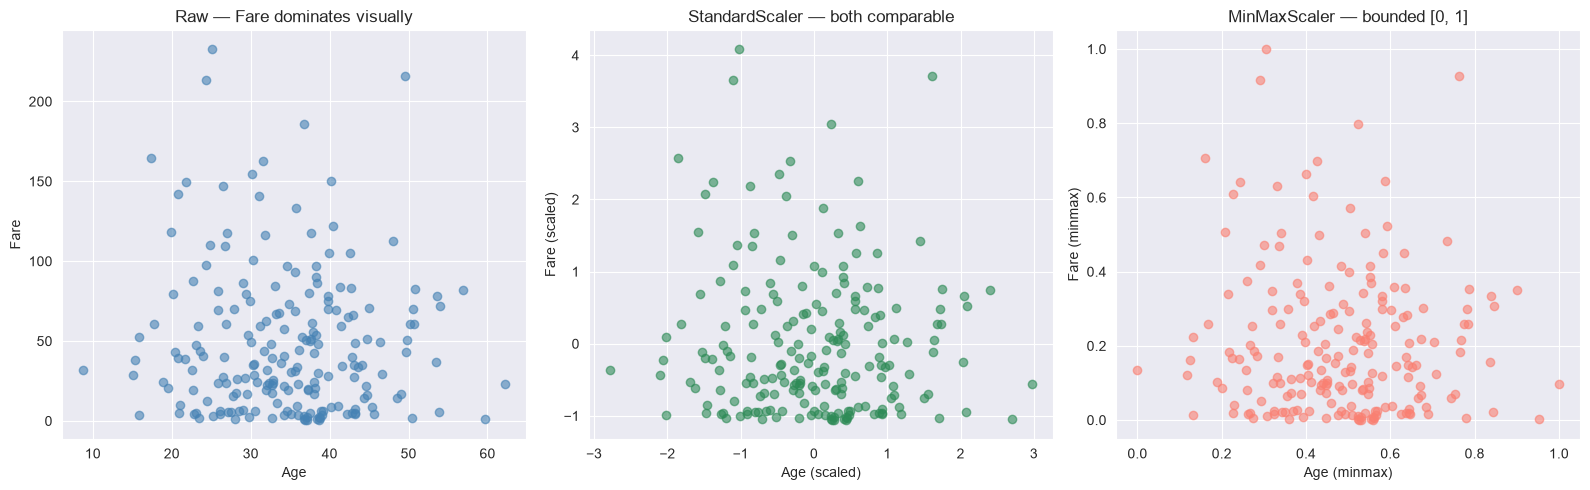

In [53]:

np.random.seed(42)
X_demo = pd.DataFrame({
    "Age":  np.random.normal(35, 10, 200),        
    "Fare": np.random.exponential(50, 200),       
})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Raw scatter
axes[0].scatter(X_demo["Age"], X_demo["Fare"], alpha=0.6, color="steelblue")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Fare")
axes[0].set_title("Raw — Fare dominates visually")

# StandardScaler
X_std = StandardScaler().fit_transform(X_demo)
axes[1].scatter(X_std[:, 0], X_std[:, 1], alpha=0.6, color="seagreen")
axes[1].set_xlabel("Age (scaled)"); axes[1].set_ylabel("Fare (scaled)")
axes[1].set_title("StandardScaler — both comparable")

# MinMaxScaler
X_mm = MinMaxScaler().fit_transform(X_demo)
axes[2].scatter(X_mm[:, 0], X_mm[:, 1], alpha=0.6, color="salmon")
axes[2].set_xlabel("Age (minmax)"); axes[2].set_ylabel("Fare (minmax)")
axes[2].set_title("MinMaxScaler — bounded [0, 1]")

plt.tight_layout()
plt.show()

##  Three Scalers — When to Use Which

| Scaler | Formula | Use When |
|--------|---------|----------|
| **StandardScaler** | `(x - mean) / std` | Data is roughly normal; default choice |
| **MinMaxScaler** | `(x - min) / (max - min)` | You need bounded values (e.g., neural nets) |
| **RobustScaler** | `(x - median) / IQR` | Data has outliers |

**Rule of thumb:** Start with StandardScaler. If outliers are severe, use RobustScaler.

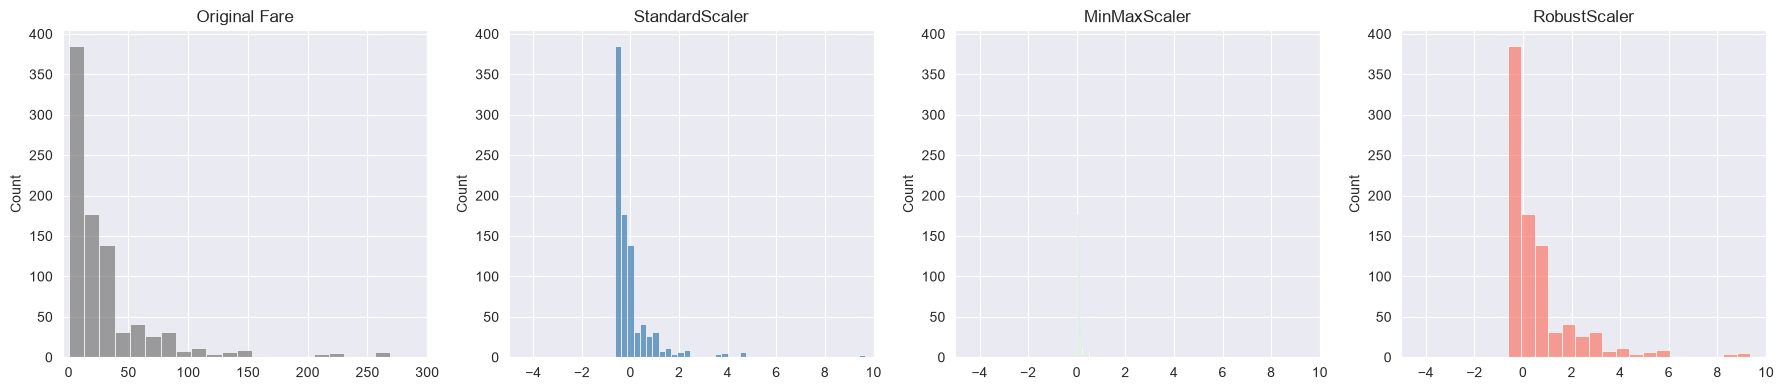

Standard → mean=+0.00, std=1.00, min=-0.65, max=9.67
MinMax   → mean=+0.06, std=0.10, min=0.00, max=1.00
Robust   → mean=+0.77, std=2.15, min=-0.63, max=21.56


In [54]:

fare = df[["Fare"]].values

scalers = {
    "Standard": StandardScaler(),
    "MinMax":   MinMaxScaler(),
    "Robust":   RobustScaler(),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))


sns.histplot(fare.flatten(), bins=40, ax=axes[0], color="gray")
axes[0].set_title("Original Fare")
axes[0].set_xlim(-5, 300)

for i, (name, scaler) in enumerate(scalers.items(), start=1):
    scaled = scaler.fit_transform(fare).flatten()
    sns.histplot(scaled, bins=40, ax=axes[i], color=["steelblue", "seagreen", "salmon"][i-1])
    axes[i].set_title(f"{name}Scaler")
    axes[i].set_xlim(-5, 10)

plt.tight_layout()
plt.show()


for name, scaler in scalers.items():
    scaled = scaler.fit_transform(fare).flatten()
    print(f"{name:8s} → mean={scaled.mean():+.2f}, std={scaled.std():.2f}, min={scaled.min():.2f}, max={scaled.max():.2f}")

##  Encoding Categorical Variables

Models speak numbers, not words. Two categories of encoders:

**For nominal** (no order — e.g., `Embarked`):
- `OneHotEncoder` — creates a binary column per category

**For ordinal** (order matters — e.g., `Pclass`, `Size: S<M<L`):
- `OrdinalEncoder` — assigns integers respecting order
- `LabelEncoder` — only for target variable, NOT features

**The classic mistake:** using `LabelEncoder` on nominal features. It tricks the model into thinking `C > B > A`.

In [55]:

le = LabelEncoder()
embarked_wrong = le.fit_transform(df["Embarked"])

print("LabelEncoder on Embarked:")
for cls, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} → {code}")

print("\nProblem: the model now thinks C < Q < S — an order that doesn't exist!")

LabelEncoder on Embarked:
  C → 0
  Q → 1
  S → 2

Problem: the model now thinks C < Q < S — an order that doesn't exist!


In [56]:
ohe = OneHotEncoder(sparse_output=False , handle_unknown="ignore")
embarked_ohe =  ohe.fit_transform(df[["Embarked"]])

print(pd.DataFrame(embarked_ohe, columns=ohe.get_feature_names_out()).head())

   Embarked_C  Embarked_Q  Embarked_S
0         0.0         0.0         1.0
1         1.0         0.0         0.0
2         0.0         0.0         1.0
3         0.0         0.0         1.0
4         0.0         0.0         1.0


In [57]:
# OrdinalEncoder for genuinely ordered categories

demo = pd.DataFrame({"Size": ["S", "M", "L", "M", "S", "L"]})

oe = OrdinalEncoder(categories=[["S", "M", "L"]])  

demo["Size_encoded"] = oe.fit_transform(demo[["Size"]])

print(demo)

  Size  Size_encoded
0    S           0.0
1    M           1.0
2    L           2.0
3    M           1.0
4    S           0.0
5    L           2.0


##  The Golden Rule — No Data Leakage

**Never** fit a scaler/encoder on the full dataset before splitting. That leaks information from the test set into training.




##  ColumnTransformer — Different Preprocessing per Column Type

Real datasets have mixed column types. `ColumnTransformer` lets you apply different transformers to different columns — all in one object.

In [58]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
categorical_features = ["Pclass", "Sex", "Embarked"]

X = df[numeric_features + categorical_features]
y = df["Survived"]

numeric_transformer = Pipeline(steps=[
  ("imputer",SimpleImputer(strategy="median")),
  ("scaler",StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer (transformers= [("num" , numeric_transformer , numeric_features),("cat", categorical_transformer, categorical_features),])

print(preprocessor)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare', 'SibSp', 'Parch',
                                  'FamilySize']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['Pclass', 'Sex', 'Embarked'])])


In [59]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# X_train_processed = preprocessor.fit_transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# print( X_train_processed.shape)
# print( X_test_processed.shape)

# feature_names = preprocessor.get_feature_names_out()
# for name in feature_names:
#     print(" ", name)

##  Full Pipeline — Preprocessing + Model

The real power: bundle everything into one object. This makes your workflow:

- **Reproducible** — one object defines the whole pipeline
- **Leak-free** — cross-validation handles fitting on train only
- **Deployable** — save the pipeline, load it in production

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])


full_pipeline.fit(X_train, y_train)

# Evaluate on test
train_acc = full_pipeline.score(X_train, y_train)
test_acc  = full_pipeline.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

Train accuracy: 0.8090
Test  accuracy: 0.8045


In [61]:
# Cross-validation on the FULL pipeline — no leakage possible
cv_scores = cross_val_score(full_pipeline, X, y, cv=5, scoring="accuracy")

print(f"CV scores: {cv_scores.round(4)}")
print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV scores: [0.7821 0.809  0.7978 0.7753 0.8427]
Mean: 0.8014 ± 0.0238


##  Common Pitfalls

| Pitfall | Fix |
|---------|-----|
| Fitting scaler before split | Always fit inside `Pipeline` or after split |
| `LabelEncoder` on nominal features | Use `OneHotEncoder` |
| Forgetting `handle_unknown="ignore"` | Set it — otherwise test categories crash prediction |
| `drop=None` in linear models | Use `drop="first"` to avoid multi-collinearity |
| Not stratifying on imbalanced data | `stratify=y` in `train_test_split` |
| Scaling target variable | Don't — only features |

##  Summary

We built a **reusable preprocessing pipeline** that:
- Imputes missing values (median for numeric, mode for categorical)
- Scales numeric features (StandardScaler)
- One-hot encodes categorical features (with `drop="first"`)
- Wraps everything + a model into a single `Pipeline`
- Works safely with cross-validation (no leakage)

**This pattern is what every production ML codebase looks like.** Master it once, reuse everywhere.

## 🚀 Next

→ [03-pca-tsne.ipynb](./03-pca-tsne.ipynb): dimensionality reduction and visualization.